In [47]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import csv
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings
from csv_reader import read_csv
from aux import set_smallest_n_zero
from disp import set_font_size, get_ordered_colors
from copy import deepcopy as copy
from analysis_tools import *
from pathlib import Path
from csv_reader import read_csv
from csv_writer import write_csv
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
import glob

new_rc_params = {
    'text.usetex': False,
    "svg.fonttype": 'none'
}
matplotlib.rcParams.update(new_rc_params)

plt.rcParams['font.size'] = 22
plt.rcParams['axes.linewidth'] = 3.0
plt.rc('font', family='Helvetica')

warnings.filterwarnings('ignore')

In [48]:
def calc_entropy(l):
    abs_l = np.abs(l)[np.abs(l) > 0]
    per_l = abs_l / np.sum(abs_l)
    return -np.dot(np.log(per_l), per_l)

def normalize(x):
    x_ = np.array(x)
    x_ = (x_ - np.mean(x_))
    return x_ / np.std(x_)

def extract_kernel(w):
    kernel = np.zeros((w.shape[0], w.shape[1] * 2), dtype=float)
    for i in range(0, w.shape[0]):
        a = slice((w.shape[1]-i), w.shape[1], 1)
        kernel[i, a] = w[i, :i]
        b = slice(w.shape[1], 2 * w.shape[1] - i, 1)
        kernel[i, b] = w[i, i:]
    return kernel

def sort_key(s):
    idx_loc = s.find('INDEX_') + 6
    s_trunc = s[idx_loc:]
    idx_und = s_trunc.find('_')
    return int(s_trunc[:idx_und])

In [52]:
def graph_perturbation_traj_fig(dir_paths, n_e=25, n_i=8, mn=True, ylim1=(0, 1.25), ylim2=(0, 1.25), fig_name='perturbation_traj'):
    light_purple = '#a873cc'
    
    T = 0.11 # Total duration of one network simulation
    dt = 1e-4 # Timestep
    t = np.linspace(0, T, int(T / dt))
    
    for i_dir, dir_path in enumerate(dir_paths):

        weights_path = os.path.join('./sims_out', dir_path, 'weights', '*')
        dynamics_path = os.path.join('./sims_out', dir_path, 'dynamics', '*')
        targets_path = os.path.join('./sims_out', dir_path, 'targeted_cells')

        last_batch_idx = None
        activation_ctr = 0

        cached_weights_exc = []
        cached_weights_rec = []
        cached_dynamics = []

        normed_ee_weights_all_networks = []
        normed_rec_weights_all_networks = []
        
        all_r_sums = []
        all_r_peaks = []
        all_r_delays = []

        def get_act_idx(p):
            activation_idx_loc = p.find('activ')
            activation_idx = int(p[activation_idx_loc + 6:p.rfind('.')])
            return activation_idx

        for i, (weights_path_i, dynamics_path_i) in enumerate(zip(sorted(glob.glob(weights_path)), sorted(glob.glob(dynamics_path)))):
            
            batch_idx_loc = weights_path_i.find('batch')
            batch_idx = int(weights_path_i[batch_idx_loc + 6:batch_idx_loc + 8])

            activation_idx = get_act_idx(weights_path_i)

            targeted_cells_file = glob.glob(os.path.join(targets_path, '*' + weights_path_i[batch_idx_loc:batch_idx_loc+8] + '*'))
            targets = read_csv(targeted_cells_file[0], read_header=False, delimiter=',', start=0).to_numpy().flatten() == 'True'

            # get perturbed indices 

            if activation_idx < 400:
                layer_colors = ['black']
            else:
                layer_colors = get_ordered_colors('winter', 12)


            if last_batch_idx is None or last_batch_idx != batch_idx:
                activation_ctr = 0
                last_batch_idx = batch_idx
                cached_weights_exc = []
                cached_weights_rec = []
                normed_ee_weights_all_networks.append([])
                normed_rec_weights_all_networks.append([])

                # fig, axs = plt.subplots(1, 1, figsize=(3 * scale, 12 * scale))
                # axs.set_yticks(np.arange(n_e))
                # axs.set_yticklabels(np.arange(n_e))


            # r = read_csv(dynamics_path_i, read_header=False, delimiter=',', start=0)
            # r = np.array(r)

            # if activation_ctr == 0:
            #     r_exc = r[:, :n_e]
            #     r_summed = np.sum(r_exc, axis=0)
            #     r_active_mask =  np.where(r_summed != 0, 1, 0).astype(bool)
            #     r_summed_safe_divide = np.where(r_active_mask, r_summed, 1)
            #     r_normed = r_exc / r_summed_safe_divide
            #     t_means = np.sum(t.reshape(t.shape[0], 1) * r_normed, axis=0)
            #     t_ordering = np.argsort(t_means)
            #     t_ordering = np.concatenate([t_ordering, np.arange(n_e, n_e + n_i)])
            #     t_means_sorted = t_means[t_ordering[:n_e]]

            # r = r[:, t_ordering]
            # r_sums = np.sum(r, axis=0)
            # r_peaks = np.max(r, axis=0)
            
            # r_exc_trial = r[:, :n_e]
            # r_summed_trial = np.sum(r_exc_trial, axis=0)
            # r_active_mask_trial =  np.where(r_summed_trial != 0, 1, 0).astype(bool)
            # r_summed_safe_divide_trial = np.where(r_active_mask_trial, r_summed_trial, 1)
            # r_normed_trial = r_exc_trial / r_summed_safe_divide_trial
            # t_means_trial = np.sum(t.reshape(t.shape[0], 1) * r_normed_trial, axis=0)
            # t_means_trial[t_means_trial == 0] = np.nan
            # r_delays = t_means_trial - t_means_sorted
            
            
            # all_r_sums.append(r_sums)
            # all_r_peaks.append(r_peaks)
            # all_r_delays.append(r_delays)

            # for cell_idx in range(n_e):
            #     r_idx = r[:, cell_idx]
            #     axs.plot(t, r_idx + 0.3 * (cell_idx), c=layer_colors[activation_ctr % len(layer_colors)])

            w = read_csv(weights_path_i, read_header=False, delimiter=',', start=0)
            w = np.array(w)

            # sorted_w = w[t_ordering, :][:, t_ordering]

            w_e_e = w[:n_e, :n_e]
            summed_e_inputs = np.sum(w_e_e, axis=1)

            w_i_e = w[:n_e, n_e:]

            w_rec = np.abs(w_i_e.sum(axis=1))

            if activation_idx < 800:
                cached_weights_rec.append(w_rec)
                cached_weights_exc.append(summed_e_inputs)
            else:
                avg_w_exc = np.mean(cached_weights_exc, axis=0)
                avg_w_rec = np.mean(cached_weights_rec, axis=0)

                normed_ee_weights_all_networks[-1].append(summed_e_inputs / np.where(avg_w_exc > 0, avg_w_exc, 1))
                normed_rec_weights_all_networks[-1].append(w_rec / avg_w_rec)

            activation_ctr += 1

        # all_r_sums = np.stack(all_r_sums)
        # all_r_peaks = np.stack(all_r_peaks)
        # all_r_durs = np.where(all_r_peaks > 0, all_r_sums / all_r_peaks, 0)
        # all_r_delays = np.stack(all_r_delays)

        normed_ee_weights_all_networks = np.stack(normed_ee_weights_all_networks)
        normed_rec_weights_all_networks = np.stack(normed_rec_weights_all_networks)
        

    return normed_ee_weights_all_networks, normed_rec_weights_all_networks, targets
                
            
    #         if mn:
    #             idx_mod = np.argmin(normed_ee_weights_all_networks[l, 0, :])
    #         else:
    #             idx_mod = np.argmax(normed_ee_weights_all_networks[l, 0, :])

    #         modified_weight_traj = normed_ee_weights_all_networks[l, :, idx_mod]
    #         unmod_weight_trajs = np.concatenate([normed_ee_weights_all_networks[l, :, 0:idx_mod], normed_ee_weights_all_networks[l, :, idx_mod+1:]], axis=1)
    #         avg_unmod_weight_traj = unmod_weight_trajs.mean(axis=1)

    #         ee_modified_trajs.append(modified_weight_traj)
    #         ee_unmod_trajs.append(avg_unmod_weight_traj)

    #         modified_weight_traj = normed_rec_weights_all_networks[l, :, idx_mod]
    #         unmod_weight_trajs = np.concatenate([normed_rec_weights_all_networks[l, :, 0:idx_mod], normed_rec_weights_all_networks[l, :, idx_mod+1:]], axis=1)
    #         avg_unmod_weight_traj = unmod_weight_trajs.mean(axis=1)

    #         rec_modified_trajs.append(modified_weight_traj)
    #         rec_unmod_trajs.append(avg_unmod_weight_traj)

    #     print(np.mean(ee_modified_trajs, axis=0).shape)
        
    #     tps = np.arange(normed_ee_weights_all_networks.shape[1]) * 5 + 1

    #     axs_w[0].plot(tps, np.mean(ee_modified_trajs, axis=0), c=light_purple)
    #     axs_w[0].scatter(tps, np.mean(ee_modified_trajs, axis=0), c=light_purple)
    #     axs_w[0].plot(tps, np.mean(ee_unmod_trajs, axis=0), c='black')
    #     axs_w[0].scatter(tps, np.mean(ee_unmod_trajs, axis=0), c='black')

    #     tps = np.arange(normed_rec_weights_all_networks.shape[1]) * 5 + 1
            
    #     axs_w[1].plot(tps, np.mean(rec_modified_trajs, axis=0), c=light_purple)
    #     axs_w[1].scatter(tps, np.mean(rec_modified_trajs, axis=0), c=light_purple)
    #     axs_w[1].plot(tps, np.mean(rec_unmod_trajs, axis=0), c='black')
    #     axs_w[1].scatter(tps, np.mean(rec_unmod_trajs, axis=0), c='black')
    
    # plt.subplots_adjust(wspace=0, hspace=0.05)
    # fig_w.savefig(f'./figures/{fig_name}.svg')
    # fig_w.savefig(f'./figures/{fig_name}.png')

ERROR! Session/line number was not unique in database. History logging moved to new session 1244


## Response to scaling down excitatory inputs to one cell

NameError: name 'normed_ee_weights_all_networks' is not defined

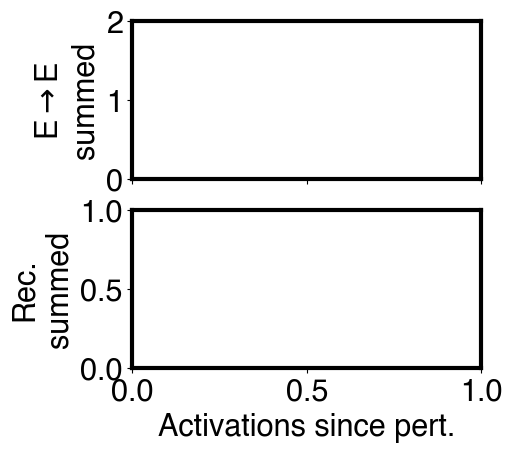

In [50]:
scale = 1.5
fig_w, axs_w = plt.subplots(2, 1, figsize=(3 * scale, 3 * scale), sharex=True)
axs_w[0].set_ylim(0, 2)
axs_w[0].set_ylabel(r'E$\rightarrow$E' + '\nsummed')
axs_w[1].set_ylabel('Rec.\nsummed')
axs_w[1].set_xlabel('Activations since pert.')
# for i in range(2):
#     axs_w[i].set_yticks([0, 0.5, 1, 1.5])
#     axs_w[i].tick_params(axis='both', which='both', direction='in', right=True, top=True)

for l in range(normed_ee_weights_all_networks.shape[0]):
    
    weight_traj_ee = np.mean(normed_ee_weights_all_networks[l, ...][:, targets], axis=1)
    axs_w[0].plot(np.arange(len(weight_traj_ee)), weight_traj_ee, c='red', alpha=0.5, lw=3)

    weight_traj_ee = np.mean(normed_ee_weights_all_networks[l, ...][:, ~targets], axis=1)
    axs_w[0].plot(np.arange(len(weight_traj_ee)), weight_traj_ee, c='black', alpha=0.5, lw=3)

    weight_traj_rec = np.mean(normed_rec_weights_all_networks[l, ...][:, targets], axis=1)
    axs_w[1].plot(np.arange(len(weight_traj_rec)), weight_traj_rec, c='red', alpha=0.5, lw=3)

    weight_traj_rec = np.mean(normed_rec_weights_all_networks[l, ...][:, ~targets], axis=1)
    axs_w[1].plot(np.arange(len(weight_traj_rec)), weight_traj_rec, c='black', alpha=0.5, lw=3)

In [84]:
def graph_single_network(normed_ee_weights_all_networks, normed_rec_weights_all_networks, idx=7, fig_name=None):
    scale = 1.2
    fig_w, axs_w = plt.subplots(2, 1, figsize=(3 * scale, 3 * scale), sharex=True)
    axs_w[0].set_ylim(0.7, 1.5)
    axs_w[1].set_ylim(0.7, 1.5)
    axs_w[0].set_xlim(0, 300)
    axs_w[0].set_ylabel(r'E$\rightarrow$E' + '\nsummed')
    axs_w[1].set_ylabel(r'I$\rightarrow$E' + '\nsummed')
    axs_w[1].set_xlabel('Activations since pert.')
    act_scale = 5

    # Add shaded region between x=250 and x=300
    for ax in axs_w:
        ax.axvspan(250, 300, color='gray', alpha=0.3)

    # Get 10 distinct colors from a continuous rainbow-like colormap (e.g., turbo or plasma)
    cmap = plt.get_cmap('turbo')  # You could also try 'plasma', 'twilight', etc.
    colors = [cmap(i / 9) for i in range(10)]  # 10 evenly spaced values from 0 to 1

    for l in range(normed_ee_weights_all_networks.shape[0]):
        if l != idx:
            continue
        for i, cell in enumerate(np.arange(10, 20)):
            c = colors[i]

            weight_traj_ee = normed_ee_weights_all_networks[l, :, cell]
            print(len( weight_traj_ee ))
            axs_w[0].plot(np.arange(len(weight_traj_ee)) * act_scale, weight_traj_ee, c=c, alpha=0.8, lw=3)

            weight_traj_rec = normed_rec_weights_all_networks[l, :, cell]
            axs_w[1].plot(np.arange(len(weight_traj_rec)) * act_scale, weight_traj_rec, c=c, alpha=0.8, lw=3)
    if fig_name is not None:
        fig_w.savefig(f'{fig_name}.svg')

In [85]:
dir_paths = [
    'stress_test_massive_pert_block_long_pert_prob_0.0_mag_5.0_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.00072_FRACI_0.75_SEED_500_2025-06-05_12:13:10.855843',
]

normed_ee_weights_all_networks_0, normed_rec_weights_all_networks_0, targets_0 = graph_perturbation_traj_fig(dir_paths, fig_name='massive_pert_figs/massive_pert_0p')

60
60
60
60
60
60
60
60
60
60


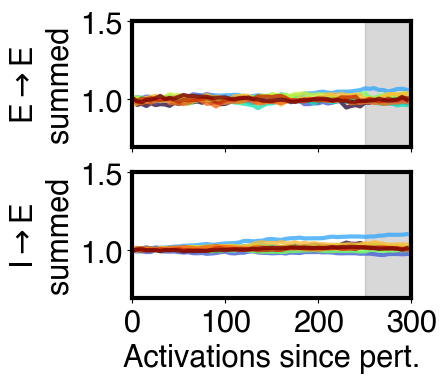

In [86]:
graph_single_network(normed_ee_weights_all_networks_0, normed_rec_weights_all_networks_0, fig_name='massive_pert_0p')

In [87]:
dir_paths = [
    'stress_test_massive_pert_block_long_pert_prob_0.25_mag_5.0_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.00072_FRACI_0.75_SEED_500_2025-06-05_11:51:49.875610',
]

normed_ee_weights_all_networks_25, normed_rec_weights_all_networks_25, targets_25 = graph_perturbation_traj_fig(dir_paths, fig_name='massive_pert_figs/massive_pert_25p')

60
60
60
60
60
60
60
60
60
60


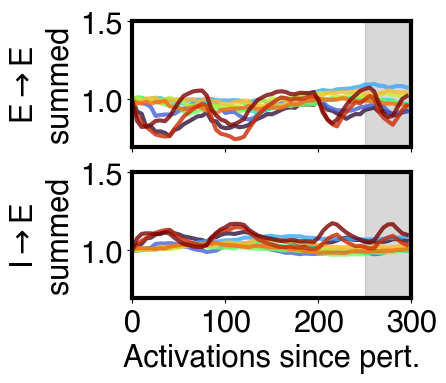

In [88]:
graph_single_network(normed_ee_weights_all_networks_25, normed_rec_weights_all_networks_25, fig_name='massive_pert_25p')

In [89]:
dir_paths = [
    'stress_test_massive_pert_block_long_pert_prob_1.0_mag_5.0_1_STD_EXPL_0.003_FIXED_True_L1_PENALTY_5e-07_5e-07_5e-07_ACT_PEN_1_CHANGEP_0.00072_FRACI_0.75_SEED_500_2025-06-05_12:05:21.202874',
]

normed_ee_weights_all_networks_100, normed_rec_weights_all_networks_100, targets_100 = graph_perturbation_traj_fig(dir_paths, fig_name='massive_pert_figs/massive_pert_100p')

60
60
60
60
60
60
60
60
60
60


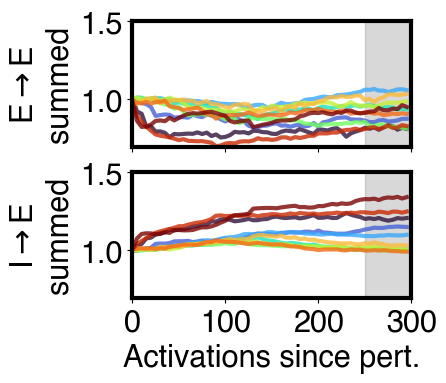

In [90]:
graph_single_network(normed_ee_weights_all_networks_100, normed_rec_weights_all_networks_100, fig_name='massive_pert_100p')

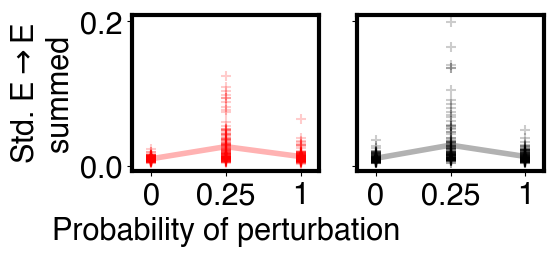

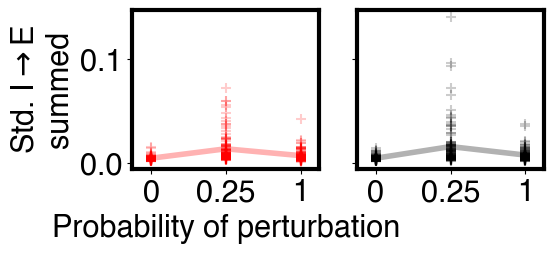

In [82]:
scale = 3

# Create separate figures for E→E and I→E
fig_ee, axs_ee = plt.subplots(1, 2, figsize=(2 * scale, scale), sharex=True, sharey=True)
fig_rec, axs_rec = plt.subplots(1, 2, figsize=(2 * scale, scale), sharex=True, sharey=True)

# Label y-axes
axs_ee[0].set_ylabel(r'Std. E$\rightarrow$E' + '\nsummed')
axs_rec[0].set_ylabel(r'Std. I$\rightarrow$E' + '\nsummed')
axs_ee[0].set_xlabel('Probability of perturbation')
axs_rec[0].set_xlabel('Probability of perturbation')

# Set x-axis ticks/limits
for ax_row in [axs_ee, axs_rec]:
    for ax in ax_row:
        ax.set_xticks(np.arange(3))
        ax.set_xticklabels([0, 0.25, 1])
        ax.set_xlim([-0.25, 2.25])

# Prepare storage
targeted_means_ee = []
untargeted_means_ee = []
targeted_means_rec = []
untargeted_means_rec = []

# Loop through data
for i, (normed_ee_weights, normed_rec_weights, targets_for_trial) in enumerate(zip(
    [normed_ee_weights_all_networks_0, normed_ee_weights_all_networks_25, normed_ee_weights_all_networks_100],
    [normed_rec_weights_all_networks_0, normed_rec_weights_all_networks_25, normed_rec_weights_all_networks_100],
    [targets_0, targets_25, targets_100])):

    # E→E variances / I removed the first neuron here as it's erratic. Also I only show 10 networks.
    ee_vars = np.std(normed_ee_weights[:10, -10:, 1:], axis=1)
    ee_vars_targeted = ee_vars[:, targets_for_trial[1:]].flatten()
    ee_vars_untargeted = ee_vars[:, ~targets_for_trial[1:]].flatten()

    axs_ee[0].scatter([i] * len(ee_vars_targeted), ee_vars_targeted, marker='+', c='red', alpha=0.2, s=60)
    axs_ee[1].scatter([i] * len(ee_vars_untargeted), ee_vars_untargeted, marker='+', c='black', alpha=0.2, s=60)

    # Recurrent variances
    rec_vars = np.std(normed_rec_weights[:10, -10:, 1:], axis=1)
    rec_vars_targeted = rec_vars[:, targets_for_trial[1:]].flatten()
    rec_vars_untargeted = rec_vars[:, ~targets_for_trial[1:]].flatten()

    axs_rec[0].scatter([i] * len(rec_vars_targeted), rec_vars_targeted, marker='+', c='red', alpha=0.2, s=60)
    axs_rec[1].scatter([i] * len(rec_vars_untargeted), rec_vars_untargeted, marker='+', c='black', alpha=0.2, s=60)

    # Save means
    targeted_means_ee.append(np.mean(ee_vars_targeted))
    untargeted_means_ee.append(np.mean(ee_vars_untargeted))
    targeted_means_rec.append(np.mean(rec_vars_targeted))
    untargeted_means_rec.append(np.mean(rec_vars_untargeted))

# Plot means
axs_ee[0].plot(np.arange(3), targeted_means_ee, c='red', lw=4, alpha=0.3)
axs_ee[1].plot(np.arange(3), untargeted_means_ee, c='black', lw=4, alpha=0.3)
axs_rec[0].plot(np.arange(3), targeted_means_rec, c='red', lw=4, alpha=0.3)
axs_rec[1].plot(np.arange(3), untargeted_means_rec, c='black', lw=4, alpha=0.3)

# Final layout and save
fig_ee.tight_layout()
fig_rec.tight_layout()
fig_ee.savefig('massive_pert_figs/std_ee_weights_split.svg')
fig_rec.savefig('massive_pert_figs/std_rec_weights_split.svg')
